In [1]:
import matplotlib.pyplot as plt 
import matplotlib.colors as colors
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import beta,norm
from scipy.ndimage import gaussian_filter
from numpy.random import default_rng
rng = default_rng()
%matplotlib inline

## Generate 2-D synthetic data

Synthetic observations are generated using a random number generator ("noise") over a 2-D grid, smoothing the noise field with a Gaussian filter, and thresholding using a percentile threshold to generate an accompanying binary field with a specific event frequency. Synthetic forecast fields are generated by taking a weighted average of the observed field with a separate random error noise field, followed by smoothing and thresholding to produce an accompanying binary forecast field. The spatial structure of the synthetic fields is controlled by the value of the standard deviation of the Gaussian kernel ("sigma"), larger sigma values will produce more contiguous binary fields with a high degree of spatial autocorrelation ("compactness"), while lower sigma values will generate binary fields that appear more intermittent or noisy ("spikiness"). Forecast bias is controlled by the percentile threshold for the forecast field. 

In the results that follow, a square domain of 333x333 points is generated with an event frequency (base rate) of $\bar x=0.1$. ) and sigma = 3 (using the multidimensional Gaussian filter from the scipy.ndimage package in "reflect" mode), which produces a moderate level of autocorrelation in the observed binary field (left panel below). A synthetic “skillful/smooth” forecast is generated with an error weight of 0.5 and a higher level of smoothing (sigma = 6; center panel below), at this original grid scale the resulting value of "probability of detection" (POD; Appendix) is $POD = 0.35$. A “random/intermittent” forecast is generated by setting the random error weight to 1 and applying a lower degree of filtering (sigma = 1), resulting in $POD = 0.1$. The same percentile threshold was used to generate unbiased forecasts ($\bar f=0.1$).

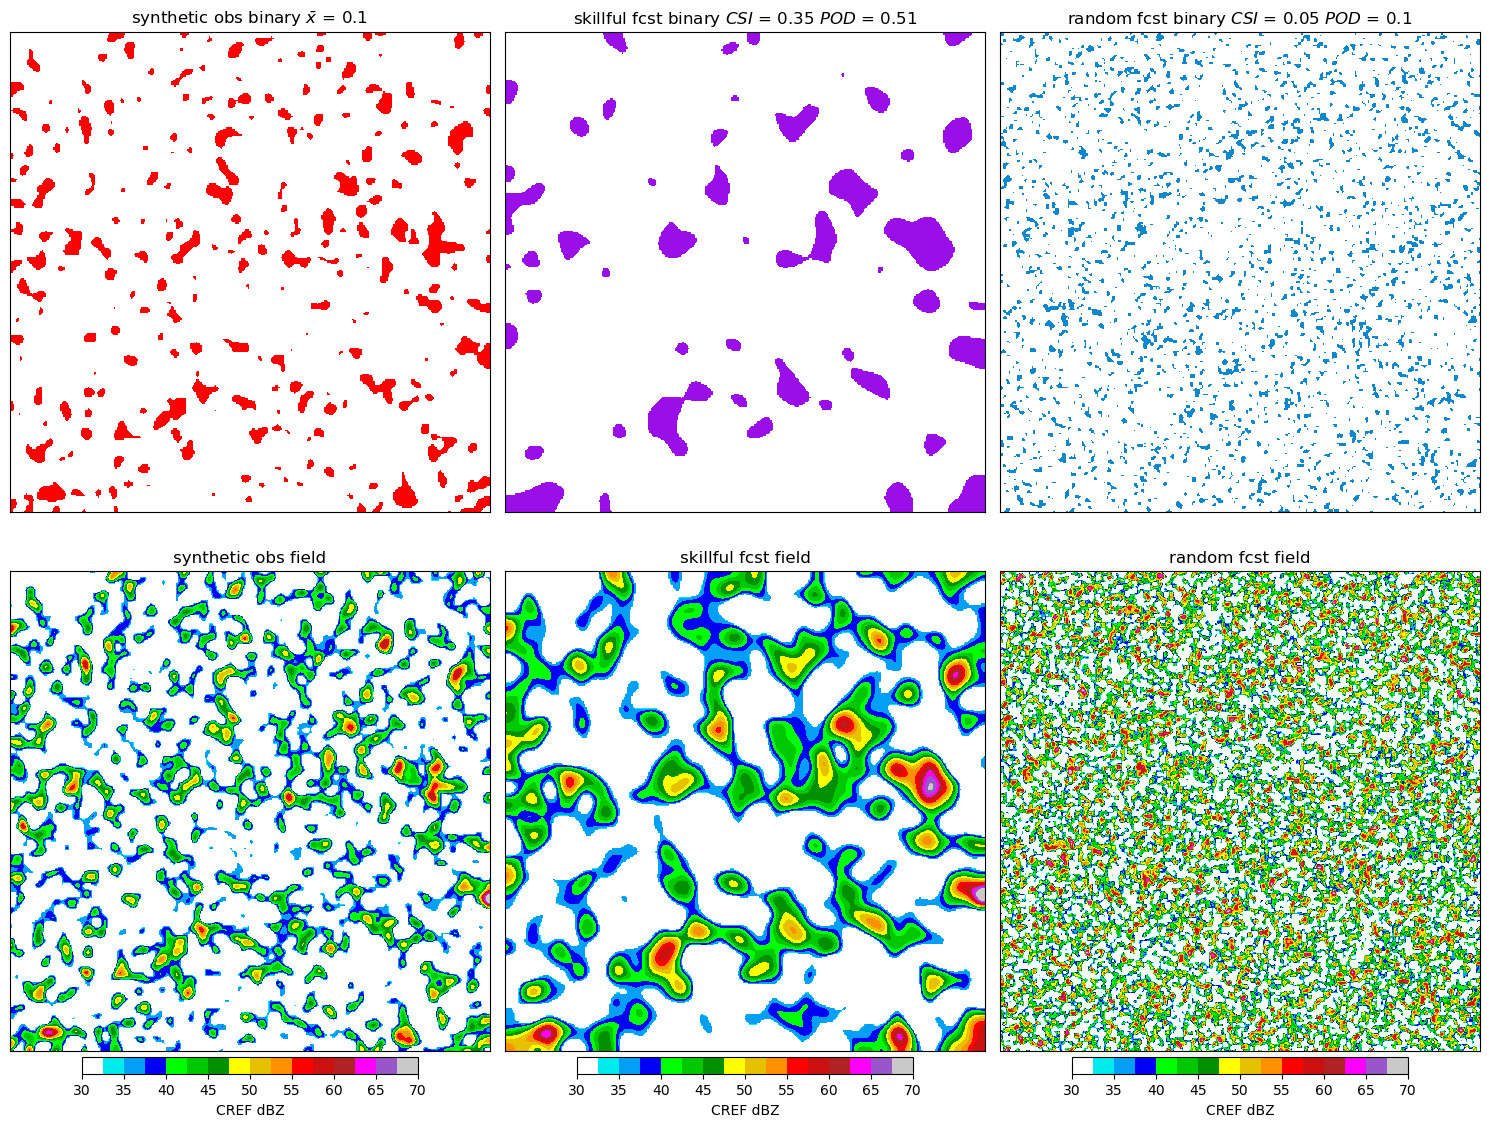

In [2]:
# synthetic 2-D observation forecast binary field generator

# colors
colorlist=['xkcd:fire engine red','xkcd:violet','xkcd:water blue','xkcd:medium green']
cmap = colors.ListedColormap(['#ffffff','#00ecec','#01a0f6','#0000f6','#00ff00','#00c800','#009000','#ffff00','#e7c000','#ff9000','#ff0000','#cd1010','#b22222','#ff00ff','#9955c9','#c9c9c9'])

# seeds for random number generators
obs_rng = np.random.default_rng(10987654321)
fcst_rng = np.random.default_rng(42)

def generate_obs_field(size, sigma, prob, rng=obs_rng):
    noise = rng.random(size)
    filtered1 = gaussian_filter(noise, sigma, mode='reflect')
    normalized = (filtered1 - np.min(filtered1)) / (np.max(filtered1) - np.min(filtered1))
    filtered = normalized*75.
    threshold = np.quantile(filtered, 1 - prob)
    return filtered, (filtered > threshold).astype('float')

def generate_forecast_field(truth_noise, sigma, prob, noise_weight, rng=obs_rng):
    noise = rng.random(truth_noise.shape)
    noise = noise_weight * noise + (1 - noise_weight) * truth_noise
    filtered1 = gaussian_filter(noise, sigma, mode='reflect')
    normalized = (filtered1 - np.min(filtered1)) / (np.max(filtered1) - np.min(filtered1))
    filtered = normalized*75.
    threshold = np.quantile(filtered, 1 - prob)
    return filtered, (filtered > threshold).astype('float')

# generate obs field with a moderate level of autocorrelation
obs_sigma = 3.

# generate a "skillful/smooth" forecast field with a higher level of compactness
skillfcst_sigma=6.
skill_error_weight=0.5

# generate a "random/spiky" forecast field with a low level of compactness
randfcst_sigma=1.
rand_error_weight=1.0

# specify base rate and bias
base_rate = 0.1
bias=1.

# domain size
ni, nj = 333, 333

# generate fields
obs_field, obs = generate_obs_field((nj, ni), obs_sigma, base_rate)
skill_field, skill_fcst = generate_forecast_field(obs_field, skillfcst_sigma, bias*base_rate, noise_weight=skill_error_weight, rng=fcst_rng)
rand_field, rand_fcst = generate_forecast_field(obs_field, randfcst_sigma, bias*base_rate, noise_weight=rand_error_weight, rng=fcst_rng)

obs_field[obs_field<35.]=0.
skill_field[skill_field<35.]=0.
rand_field[rand_field<35.]=0.
# calculate CSI
skill_csi=np.sum(obs*skill_fcst)/(np.sum(obs)+np.sum(skill_fcst)-np.sum(obs*skill_fcst))
rand_csi=np.sum(obs*rand_fcst)/(np.sum(obs)+np.sum(skill_fcst)-np.sum(obs*rand_fcst))
skill_pod=np.sum(obs*skill_fcst)/np.sum(obs)
rand_pod=np.sum(obs*rand_fcst)/np.sum(obs)

# plot binary fields
fig,ax = plt.subplots(2,3,figsize=(15,12))
axs=ax.flat

cmap_obs=colors.ListedColormap(['white',colorlist[0]])
axs[0].imshow(obs, cmap=cmap_obs, origin='lower')
axs[0].set_title(r'synthetic obs binary $\bar x$ = '+f'{base_rate}')
axs[0].set_xticks([])
axs[0].set_yticks([])

cmap_fcst=colors.ListedColormap(['white',colorlist[1]])
axs[1].imshow(skill_fcst, cmap=cmap_fcst, origin='lower')
axs[1].set_title(r'skillful fcst binary $CSI$ = '+f'{np.round(skill_csi,2)} $POD$ = '+f'{np.round(skill_pod,2)}')
axs[1].set_xticks([])
axs[1].set_yticks([])

cmap_rand=colors.ListedColormap(['white',colorlist[2]])
axs[2].imshow(rand_fcst, cmap=cmap_rand, origin='lower')
axs[2].set_title(r'random fcst binary $CSI$ = '+f'{np.round(rand_csi,2)} $POD$ = '+f'{np.round(rand_pod,2)}')
axs[2].set_xticks([])
axs[2].set_yticks([])

# plot continuous fields
sc=axs[3].imshow(obs_field,cmap=cmap,vmin=30.,vmax=70., origin='lower')
cbar=plt.colorbar(sc,orientation='horizontal',shrink=0.7,pad=0.01,ax=axs[3])
cbar.set_label('CREF dBZ')
axs[3].set_title('synthetic obs field')
axs[3].set_xticks([])
axs[3].set_yticks([])

sc=axs[4].imshow(skill_field,cmap=cmap,vmin=30.,vmax=70., origin='lower')
cbar=plt.colorbar(sc,orientation='horizontal',shrink=0.7,pad=0.01,ax=axs[4])
cbar.set_label('CREF dBZ')
axs[4].set_title('skillful fcst field')
axs[4].set_xticks([])
axs[4].set_yticks([])

sc=axs[5].imshow(rand_field,cmap=cmap,vmin=30.,vmax=70., origin='lower')
cbar=plt.colorbar(sc,orientation='horizontal',shrink=0.7,pad=0.01,ax=axs[5])
cbar.set_label('CREF dBZ')
axs[5].set_title('random fcst field')
axs[5].set_xticks([])
axs[5].set_yticks([])

plt.tight_layout()